(scrna_seq_workflow)=

# Identify PBMC populations with scRNA-seq

Single-cell RNA sequencing measures RNA counts in individual cells, describing each
cell through the genes it expresses. Peripheral blood mononuclear cells (PBMCs) contain
several immune populations, including T cells, B cells, monocytes, NK cells, and rarer
dendritic cells. Their expression profiles help us distinguish these populations and
later investigate how their states differ across conditions.

A cluster number tells us which cells have similar RNA profiles. To give a cluster a biological
name, we need marker-gene evidence rather than just a group of similar cells. Here we will
inspect a prepared blood-cell analysis, compare a small marker panel, and assign broad
cell types.

Start with the {ref}`quick start <quickstart>` if you want to run the standard pipeline on your
own counts. This page uses saved results so we can concentrate on interpreting them.

## Open the analysis and look at the clusters

In [1]:
# Open count stores and run CyteArc analyses.
import cytearc

# Keep routine execution messages out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr")

# Open the saved analysis and its exact results.
run = ds.pipeline.open(label="docs_default")

# Inspect the opened store's cells and features.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-09T00:12:08.098898Z | Wall time: 10.793 s

The prepared run contains the selected cells, clusters, and UMAP coordinates. Rank markers for its clusters with
`ds.markers.search(run["clusters"], features=run["feature_universe"])`, as [](annotation.ipynb)
does. Its name is `docs_default`, but it used dataset-specific filtering, 500 variable genes, and
15 PCs. Those settings preserve the example we will interpret; they are not the current pipeline
defaults.

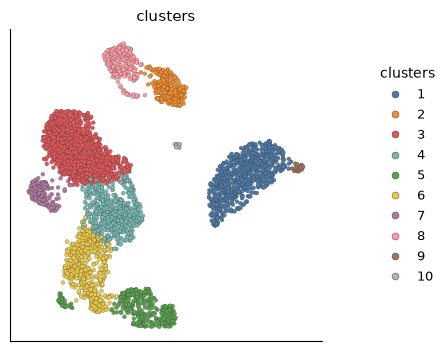

Started: 2026-10-09T00:12:18.896225Z | Wall time: 2.622 s

In [2]:
# Locate the numbered clusters in the prepared PBMC UMAP.
ds.plots.embedding(run=run, color_by="clusters")

The UMAP places the clusters in two dimensions so we can inspect the main groups and
smaller populations. Nearby cells have similar profiles in this view, but the size of a
gap between clusters does not establish how different their cell types are. We will
use marker expression to investigate their identities next.

## Compare markers before naming the groups

With the clusters in view, we can compare several marker genes for each broad lineage.
Using a panel helps us look for consistent evidence across genes rather than assigning
a name from one signal. In a dot plot, a larger dot means a larger fraction of cells
express the gene in that cluster; its colour shows the mean expression in the cluster.

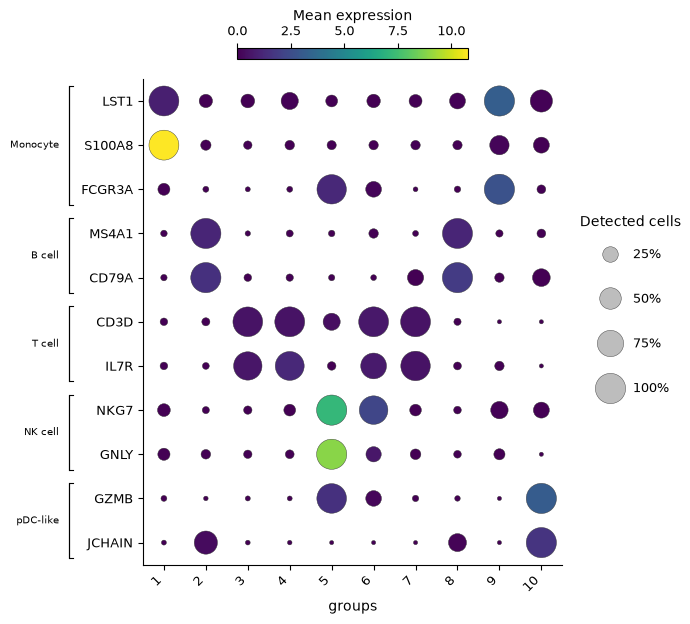

Started: 2026-10-09T00:12:21.522631Z | Wall time: 2.286 s

In [3]:
# Choose several markers for each broad lineage.
marker_panel = {
    "Monocyte": ["LST1", "S100A8", "FCGR3A"],
    "B cell": ["MS4A1", "CD79A"],
    "T cell": ["CD3D", "IL7R"],
    "NK cell": ["NKG7", "GNLY"],
    "pDC-like": ["GZMB", "JCHAIN"],
}

# Compare marker expression and detection across the selected groups.
ds.plots.dotplot(features=marker_panel, groups=run["clusters"])

MS4A1 and CD79A support B-cell identities; CD3D and IL7R support T cells. NKG7 and GNLY help
identify cytotoxic populations, so compare them with the T-cell markers before calling a group
NK cells. LST1, S100A8, and FCGR3A help distinguish the monocyte populations.

GZMB together with JCHAIN suggests a small pDC-like population. This is a provisional label:
the [](annotation.ipynb) tutorial examines IL3RA, other marker evidence, and competing
interpretations before refining the labels.

For a gene with much lower expression than the others, it can help to scale each gene separately.
The next plot changes only the colour scale: values are now relative within each gene, so colours
cannot be used to compare absolute expression between different genes.

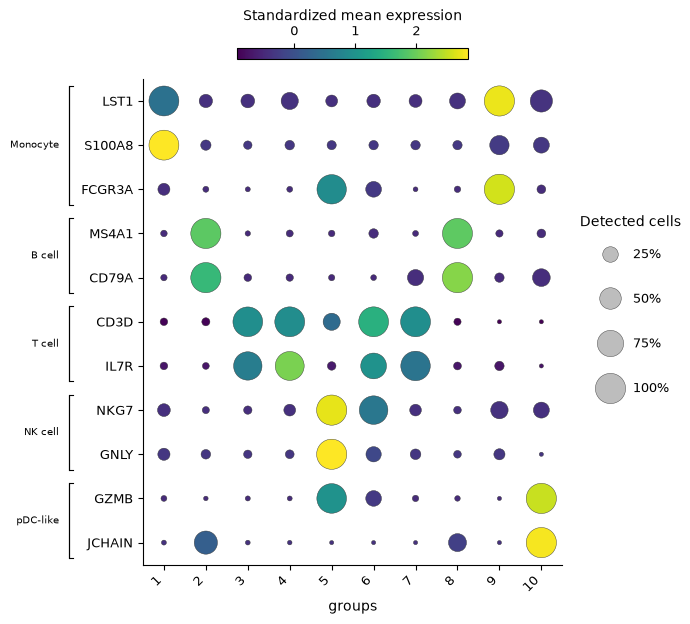

Started: 2026-10-09T00:12:23.812770Z | Wall time: 2.269 s

In [4]:
# Compare marker expression and detection across the selected groups.
ds.plots.dotplot(features=marker_panel, groups=run['clusters'], standardize='feature')

## Give the clusters broad names

Read the dot plots by cluster before assigning names: B-cell markers support clusters 2 and 8,
T-cell markers support 3, 4, 6, and 7, and the monocyte markers support 1 and 9. Cluster 5 has the
NK-like cytotoxic pattern. We retain a provisional pDC-like label for cluster 10.

Several clusters share a label because they belong to the same lineage. These cluster numbers
belong to this saved result. Even a new analysis of the same counts can number its clusters
differently, so check the marker evidence again before reusing this mapping.

In [5]:
# Assign broad names supported by this saved result's marker evidence.
cell_type_by_cluster = {
    "1": "CD14 monocytes",
    "2": "B cells",
    "3": "T cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "monocytes",
    "10": "pDC-like cells",
}

# Review the names assigned to the prepared clusters.
cell_type_by_cluster

{'1': 'CD14 monocytes',
 '2': 'B cells',
 '3': 'T cells',
 '4': 'T cells',
 '5': 'NK cells',
 '6': 'T cells',
 '7': 'T cells',
 '8': 'B cells',
 '9': 'monocytes',
 '10': 'pDC-like cells'}

Started: 2026-10-09T00:12:26.085632Z | Wall time: 0.009 s

Save the names in the cell table. The run contains only the analyzed cells, while the cell table
contains every cell, so fill the other rows with an explicit label before inserting the column.

In [6]:
# Work with numeric arrays and cell masks.
import numpy as np

# Locate the analyzed cells within the full cell table.
analysis_cells = run.cells.fetch_all("I").astype(bool)

# Read cluster labels in the selected cells' order.
cluster_values = run.cells.fetch("clusters").astype(str)

# Give cells outside the analysis an explicit label.
cell_types = np.full(ds.cells.N, "Not analyzed", dtype=object)

# Fill analyzed rows with their cluster's chosen cell-type label.
cell_types[analysis_cells] = [cell_type_by_cluster[value] for value in cluster_values]

# Save the calculated values in the cell table.
ds.cells.insert("pbmc_cell_type", cell_types, overwrite=True)

# Count analyzed cells assigned to each cell type.
labels, counts = np.unique(cell_types[analysis_cells], return_counts=True)

# Show the number of analyzed cells assigned to each cell type.
{str(label): int(count) for label, count in zip(labels, counts, strict=True)}

{'B cells': 495,
 'CD14 monocytes': 716,
 'NK cells': 318,
 'T cells': 2379,
 'monocytes': 25,
 'pDC-like cells': 15}

Started: 2026-10-09T00:12:26.098328Z | Wall time: 0.076 s

This writes our labels to `pbmc_cell_type`; rerunning the cell replaces that column. The saved
clusters remain available. Use their UMAP to display the new names:

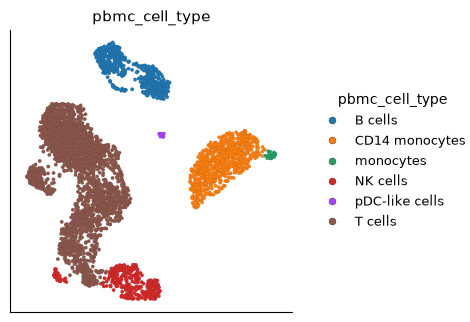

Started: 2026-10-09T00:12:26.177616Z | Wall time: 0.580 s

In [7]:
# Show the assigned broad cell types on the saved UMAP.
ds.plots.embedding(layout=run["umap"], color_by="pbmc_cell_type")

## Build on this analysis

Continue with [](annotation.ipynb) to distinguish finer cell types and states using supporting and
negative markers. Before interpreting your own data, review [](quality_control.ipynb) and check
that the retained cells make sense for your study.

When the first result raises a specific question, use [](feature_selection.ipynb),
[](dimensionality_reduction.ipynb), or [](clustering.ipynb) to compare one choice at a time.
[](graph_construction.ipynb) explains the individual computation steps, and
[](reuse_and_tracing.ipynb) shows how to reopen and compare saved analyses.

Marker tests here compare cells, not biological replicates. For differences between conditions,
use a suitable study design and the [](pseudobulk_and_differential_expression.ipynb) or
[](condition_comparisons.ipynb) guide.